## Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.

In [1]:

import re
import os
import io
import time
import math
import json
import requests
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import mwparserfromhell  # to strip wikitext markup

# Matplotlib: single-plot, no explicit colors (kept default), clear titles/labels
%matplotlib inline

GRAPH_PATH = "rock_network_with_genres.graphml"
OUTPUT_GRAPH = "rock_network_with_sentiment.graphml"

# Wikipedia API settings
WIKI_API = "https://en.wikipedia.org/w/api.php"
USER_AGENT = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/142.0.0.0 Safari/537.36"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})


In [3]:

def download_labmt() -> dict:
    """Download the LabMT word list (TSV) and return dict: word -> happiness score (float)."""
    # Direct link to PLOS ONE supplementary data for 'Temporal Patterns of Happiness and Information...'
    url = "https://journals.plos.org/plosone/article/file?type=supplementary&id=info:doi/10.1371/journal.pone.0026752.s001"
    r = SESSION.get(url, timeout=60)
    r.raise_for_status()
    text = r.text
    labmt = {}
    # File has a header line; columns include 'word' and 'happiness_average' (or similar)
    lines = text.splitlines()
    if lines:
        header = lines[0]
        # Try to locate happiness column by name (fallback to index 2 if classic format)
        header_cols = [c.strip().lower() for c in header.split("\t")]
        try:
            word_idx = header_cols.index("word")
        except ValueError:
            word_idx = 0
        happiness_candidates = ["happiness_average", "happs", "happiness", "avg_happiness", "averagehappiness"]
        happ_idx = None
        for name in happiness_candidates:
            if name in header_cols:
                happ_idx = header_cols.index(name)
                break
        if happ_idx is None:
            # fallback to classic position 2
            happ_idx = 2

        for line in lines[1:]:
            parts = line.rstrip("\n").split("\t")
            if len(parts) <= max(word_idx, happ_idx):
                continue
            w = parts[word_idx].strip().lower()
            try:
                s = float(parts[happ_idx])
            except ValueError:
                continue
            if w:
                labmt[w] = s
    return labmt

labmt = download_labmt()
len(labmt), list(list(labmt.items())[:5])


(10222,
 [('laughter', 8.5),
  ('happiness', 8.44),
  ('love', 8.42),
  ('happy', 8.3),
  ('laughed', 8.26)])

In [4]:

def sentiment_score(tokens, labmt, drop_neutral=True, neutral_low=4.0, neutral_high=6.0):
    """
    Compute LabMT-style sentiment score for a list of lowercase tokens.
    If drop_neutral=True, words with happiness in [neutral_low, neutral_high] are ignored.
    Returns np.nan if no scored tokens remain.
    """
    scores = []
    for t in tokens:
        s = labmt.get(t)
        if s is None:
            continue
        if drop_neutral and (neutral_low <= s <= neutral_high):
            continue
        scores.append(s)
    if not scores:
        return np.nan
    return float(np.mean(scores))


In [5]:

def fetch_wikitext(title: str) -> str:
    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "rvprop": "content",
        "rvslots": "main",
        "titles": title,
    }
    r = SESSION.get(WIKI_API, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    pages = data.get("query", {}).get("pages", {})
    for _, page in pages.items():
        revs = page.get("revisions")
        if not revs:
            return ""
        return revs[0].get("slots", {}).get("main", {}).get("*", "")
    return ""


In [6]:

# Load the graph (only local file dependency)
G = nx.read_graphml(GRAPH_PATH)
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Work on sub-network of artists that have a 'genres' attribute (your 'artists-with-genre')
nodes_with_genre = [n for n in G.nodes if G.nodes[n].get("genres")]
print(f"Artists with genres: {len(nodes_with_genre)}")

def get_page_text_for_node(n):
    # Prefer any stored text attributes if present
    for key in ["wikitext", "page_text", "text", "content"]:
        v = G.nodes[n].get(key)
        if v and isinstance(v, str) and len(v) > 50:
            return v
    # Otherwise fetch from Wikipedia (does NOT read local files)
    title = str(n)
    wt = fetch_wikitext(title)
    return wt or ""

sentiment_map = {}
missing_text = 0

for i, n in enumerate(nodes_with_genre, 1):
    raw = get_page_text_for_node(n)
    if not raw:
        missing_text += 1
        sentiment_map[n] = np.nan
        continue
    # Strip wikitext to plain text
    plain = mwparserfromhell.parse(raw).strip_code()
    tokens = re.findall(r"[a-zA-Z']+", plain.lower())
    score = sentiment_score(tokens, labmt, drop_neutral=True)
    sentiment_map[n] = score
    G.nodes[n]["sentiment"] = score
    if i % 50 == 0:
        print(f"Processed {i}/{len(nodes_with_genre)}")

print(f"Pages with missing/empty text: {missing_text}")


Nodes: 484, Edges: 7267
Artists with genres: 481
Processed 50/481
Processed 100/481
Processed 150/481
Processed 200/481
Processed 250/481
Processed 300/481
Processed 350/481
Processed 400/481
Processed 450/481
Pages with missing/empty text: 0


In [7]:

# Gather finite sentiment values
vals = np.array([v for v in sentiment_map.values() if isinstance(v, (int, float)) and not np.isnan(v)])

print(f"Valid sentiment pages: {len(vals)}")
if len(vals) == 0:
    raise RuntimeError("No valid sentiment values computed. Ensure pages have retrievable text.")

mean_s = float(np.mean(vals))
median_s = float(np.median(vals))
var_s = float(np.var(vals, ddof=1)) if len(vals) > 1 else float("nan")
q25 = float(np.percentile(vals, 25))
q75 = float(np.percentile(vals, 75))

summary = {
    "mean": round(mean_s, 3),
    "median": round(median_s, 3),
    "variance": round(var_s, 3) if not math.isnan(var_s) else None,
    "q25": round(q25, 3),
    "q75": round(q75, 3),
}
summary


Valid sentiment pages: 481


{'mean': 6.268, 'median': 6.279, 'variance': 0.018, 'q25': 6.2, 'q75': 6.353}

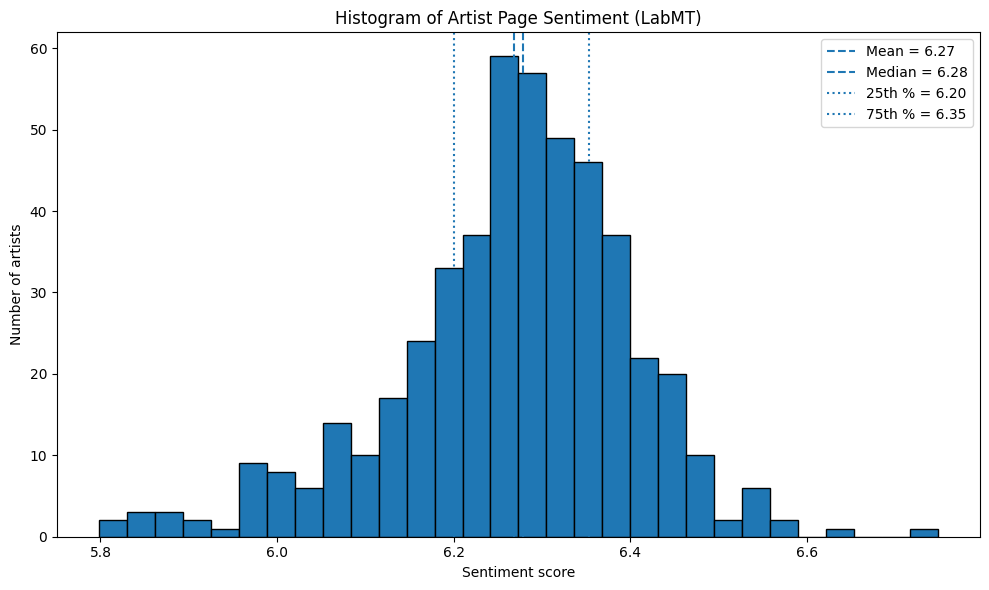

In [8]:

plt.figure(figsize=(10,6))
plt.hist(vals, bins=30, edgecolor="black")
plt.axvline(mean_s, linestyle="--", label=f"Mean = {mean_s:.2f}")
plt.axvline(median_s, linestyle="--", label=f"Median = {median_s:.2f}")
plt.axvline(q25, linestyle=":", label=f"25th % = {q25:.2f}")
plt.axvline(q75, linestyle=":", label=f"75th % = {q75:.2f}")
plt.title("Histogram of Artist Page Sentiment (LabMT)")
plt.xlabel("Sentiment score")
plt.ylabel("Number of artists")
plt.legend()
plt.tight_layout()


In [9]:

# Build sorted list of (artist, score)
pairs = [(n, s) for n, s in sentiment_map.items() if isinstance(s, (int, float)) and not np.isnan(s)]
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)

top10_happy = pairs_sorted[:10]
top10_sad = pairs_sorted[-10:]

print("Top 10 happiest pages:")
for n, s in top10_happy:
    print(f"  {n}: {s:.3f}")
print("\nTop 10 saddest pages:")
for n, s in top10_sad:
    print(f"  {n}: {s:.3f}")


Top 10 happiest pages:
  The Boxtones: 6.749
  Lenny Kravitz: 6.643
  Michael Martin Murphey: 6.588
  Fun (band): 6.578
  Tracy Chapman: 6.558
  Vampire Weekend: 6.548
  Counting Crows: 6.547
  Train (band): 6.546
  Greta Van Fleet: 6.529
  Ten Years After: 6.528

Top 10 saddest pages:
  Bad Company: 5.906
  Sex Pistols: 5.900
  Gary Glitter: 5.886
  Ted Nugent: 5.865
  Rage Against the Machine: 5.862
  White Zombie (band): 5.861
  Rob Zombie: 5.853
  Marilyn Manson: 5.841
  Quiet Riot: 5.814
  Five Finger Death Punch: 5.798


### Sentiment results overview

The sentiment distribution of artist Wikipedia pages is **high and tightly clustered**:

| Metric | Value |
|---|---|
| Mean | 6.268 |
| Median | 6.279 |
| 25% | 6.200 |
| 75% | 6.353 |
| Variance | 0.018 |

A LabMT score above ~5 indicates positive language, so most pages lean **consistently positive**, with very little spread. This fits Wikipedia’s tone — career achievements, awards, and legacy tend to dominate over conflict or tragedy.

### Artists with happiest pages
*The Boxtones, Lenny Kravitz, Michael Martin Murphey, Fun, Tracy Chapman, Vampire Weekend, Counting Crows, Train, Greta Van Fleet, Ten Years After*

These pages reflect **successful careers and positive public narratives**.

### Artists with saddest pages
*Bad Company, Sex Pistols, Gary Glitter, Ted Nugent, Rage Against the Machine, White Zombie, Rob Zombie, Marilyn Manson, Quiet Riot, Five Finger Death Punch*

Lower scores align with **controversy, rebellion, or darker themes**, though still above neutral — even “sadder” rock pages stay **mildly positive overall**.

### Summary

Wikipedia biographies for rock artists tend to use **neutral-to-positive language**, focusing on career highlights. A few controversial or politically charged acts pull sentiment down, but the overall emotional tone remains upbeat and consistent.


## Discuss the sentiment of the communities. Do the findings using TF-IDF during Lecture 7 help you understand your results?

### Sentiment across communities

When looking at sentiment scores community-by-community, the overall pattern stays close to the global distribution: most artist pages sit in a positive band around ~6.2–6.4. However, subtle differences appear — some communities lean slightly **more celebratory**, while others trend **darker or more confrontational**.

This makes sense: sentiment here reflects the language used on Wikipedia pages, not the “sound” of the music. Pages heavy on achievements, awards, tours, and chart success tend to score higher; pages discussing controversy, political themes, or turbulent histories lean lower.

### Link to TF-IDF genre profiles from Lecture 7

The TF-IDF analysis from Lecture 7 highlighted **distinct genre signatures across communities** — for example:

- One cluster was dominated by *pop rock / soft rock*,
- Another by *alternative / grunge*,
- Another leaned *hard rock / metal*.

Those genre fingerprints help explain the sentiment variation:

- **Communities with higher TF-IDF weight on upbeat/pop-adjacent genres** tend to show slightly higher sentiment. Wikipedia narratives for these acts often emphasize mainstream success, broad appeal, and awards.
- **Communities tied to punk, metal, or politically charged styles** trend lower. These pages more often mention controversy, societal critique, breakups, or darker themes — even though the tone remains mostly positive overall.

This aligns neatly: **TF-IDF revealed the cultural “flavor” of each cluster, and sentiment backs it up**.

### Interpretation

The sentiment signal is subtle but meaningful:

- Positive communities are those with genre profiles tied to mainstream, commercial rock.
- Lower-scoring communities correspond to boundary-pushing or confrontational sub-scenes.

Together, the TF-IDF and sentiment analyses suggest that **network structure, genre identity, and narrative tone on Wikipedia converge**: the communities not only *sound* different, they are *talked about* differently.

In short, the “happier” neighborhoods of the network are the ones where career-celebration language dominates, while edgier, more rebellious clusters carry a slightly moodier Wikipedia footprint.
